In [4]:
from cyvcf2 import VCF, Writer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from pybedtools import BedTool
import seaborn as sns
import tqdm

In [5]:
# UL-ONT R10.4.1, Duplex, Dorado: https://s3-us-west-2.amazonaws.com/human-pangenomics/T2T/scratch/HG002/sequencing/ont/11_16_22_R1041_UL_HG002_dorado0.4.0/
# UL-ONT R9.4.1, Duplex, Guppy: https://s3-us-west-2.amazonaws.com/human-pangenomics/T2T/scratch/HG002/sequencing/ont/03_08_22_R941_HG002_rebasecalling-guppy-6.3.7/
# UL-ONT R10.4.1, Duplex, Dorado Q28: https://epi2me.nanoporetech.com/gm24385_ncm23_preview/#sample-preparation-and-analysis
# ONT R10.4.1, Simplex, Dorado: https://epi2me.nanoporetech.com/giab-2025.01/


In [6]:

base_dir = '/scratch/gpfs/AKEY/apfennig/LongHap/HG002/deepvariant/'
eval_pattern = base_dir + 'deep_variant_hifi_hs1.minimap2.{seq_tech}.chr{chrom}.filtered_{variants}.{tool}_phased.evaluation.{sites}.tab'
eval_complex_pattern = base_dir + 'deep_variant_hifi_hs1.minimap2.{seq_tech}.chr{chrom}.filtered_snps_indels.{tool}_phased.evaluation_complex_variants.shared_sites.tab'
stats_pattern = base_dir + 'deep_variant_hifi_hs1.minimap2.{seq_tech}.chr{chrom}.filtered_{variants}.{tool}_phased.stats.tsv'
stats_complex_pattern = base_dir + 'deep_variant_hifi_hs1.minimap2.{seq_tech}.chr{chrom}.filtered_snps_indels.{tool}_phased.stats_complex_variants.tsv'
compute_pattern = base_dir + 'deep_variant_hifi_hs1.minimap2.{seq_tech}.chr{chrom}.filtered_{variants}.{tool}.benchmark'
seq_tech = 'hifi'
variants = 'snps_indels'
sites="shared_sites"


all_tools = ['WhatsHap', 'HapCUT2', 'Longphase', "WhatsHap + MethPhaser", 'LongHap Meth', 
             'LongHap']
tools = ['WhatsHap', 'HapCUT2', 'Longphase', "WhatsHap + MethPhaser", 'LongHap Meth', 'LongHap']
chroms = np.arange(1, 23)

eval_dict = {}
eval_complex_dict = {}
stats_dict = {}
stats_complex_dict = {}
compute_dict = {}

colors = {'WhatsHap': 'grey', 'HapCUT2': "grey", "Longphase": "grey", "WhatsHap + MethPhaser": "grey",
          "LongHap": "blue", "LongHap Meth": "red"}
markers = {'WhatsHap': '^', 'HapCUT2': 'v',  "Longphase": "x", "WhatsHap + MethPhaser": 's', 
           "LongHap": "o", "LongHap Meth": "o"}
for tool in all_tools:
    df_eval = pd.concat([pd.read_csv(eval_pattern.format(chrom=chrom, 
                                                         tool=tool.replace(' ', '_').replace("+", "and").lower(), 
                                                         variants=variants, seq_tech=seq_tech, sites=sites), 
                                     sep='\t') for chrom in chroms])
    df_eval_complex = pd.concat([pd.read_csv(eval_complex_pattern.format(chrom=chrom, 
                                                         tool=tool.replace(' ', '_').replace("+", "and").lower(), 
                                                         variants=variants, seq_tech=seq_tech, sites=sites), 
                                     sep='\t') for chrom in chroms])
    df_stats = pd.concat([pd.read_csv(stats_pattern.format(chrom=chrom, 
                                                           tool=tool.replace(' ', '_').replace("+", "and").lower(), 
                                                           variants=variants, seq_tech=seq_tech), 
                                      sep='\t') for chrom in chroms])
    df_stats_complex = pd.concat([pd.read_csv(stats_complex_pattern.format(chrom=chrom, 
                                                           tool=tool.replace(' ', '_').replace("+", "and").lower(), 
                                                           variants=variants, seq_tech=seq_tech), 
                                      sep='\t') for chrom in chroms])
    if tool == 'WhatsHap + MethPhaser':
        compute_pattern_meth = base_dir + "{seq_tech}_minimap2_methphaser_{chrom}.{variants}.benchmark"
        compute_pattern_meth_post = base_dir + "{seq_tech}_minimap2_methphaser_{chrom}_post_processing.{variants}.benchmark"
        df_meth = pd.concat([pd.read_csv(compute_pattern_meth.format(chrom=chrom, 
                                                                     variants=variants, 
                                                                     seq_tech=seq_tech), 
                                         sep='\t') for chrom in chroms])
        df_meth_post = pd.concat([pd.read_csv(compute_pattern_meth_post.format(chrom=chrom, 
                                                                               variants=variants,
                                                                               seq_tech=seq_tech), 
                                              sep='\t') for chrom in chroms])
        df_compute = df_meth + df_meth_post
        df_compute.max_rss = np.stack([df_meth.max_rss.values, df_meth_post.max_rss.values]).max(axis=0)
    else:
        df_compute = pd.concat([pd.read_csv(compute_pattern.format(chrom=chrom, 
                                                                   tool=tool.replace(' ', '_').replace("+", "and").lower(), 
                                                                   variants=variants, seq_tech=seq_tech),
                                            sep='\t') for chrom in chroms])
    eval_dict[tool] = df_eval
    eval_complex_dict[tool] = df_eval_complex
    stats_dict[tool] = df_stats
    stats_complex_dict[tool] = df_stats_complex
    compute_dict[tool] = df_compute
    


WhatsHap: 99.22314595606453 (0.9885822170277803-0.9949438770350895; 1.24126756890228%)
HapCUT2: 97.13373341408358 (0.9439558801609778-0.9792244520585196; 1.1718927130095678%)
Longphase: 90.7273027583549 (0.8770308540766135-0.9236909701639993; 1.0025001820520911%)
WhatsHap + MethPhaser: 99.196443318835 (0.9876831789984717-0.9943982161309621; 1.0534465964183926%)
LongHap Meth: 94.28646148763971 (0.8911909375465792-0.957082917082917; 0.9915183719945695%)
LongHap: 94.01337884710675 (0.8861231181994336-0.9544055944055944; 1.0140170359547074%)


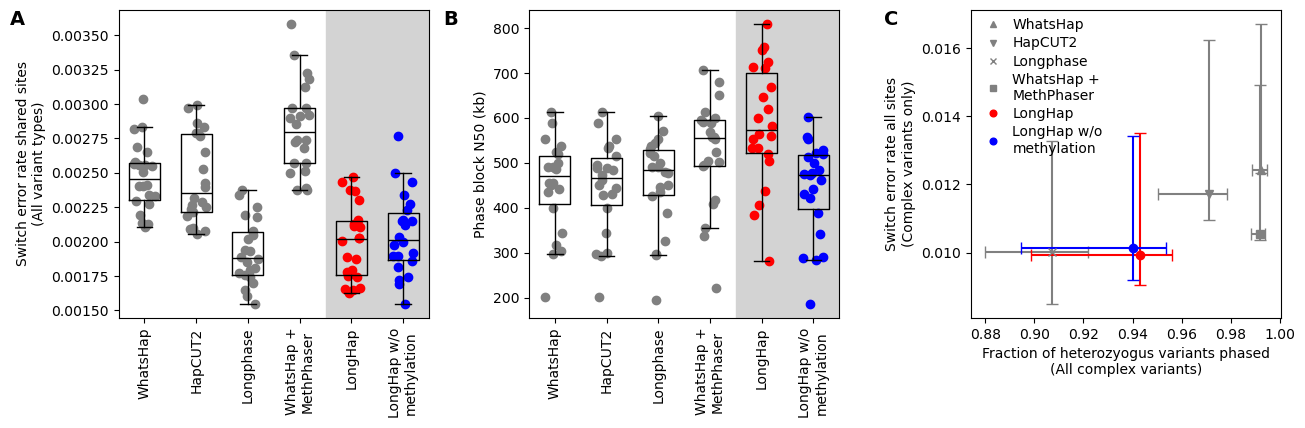

In [7]:
def make_box_plot(data_dict, tools, colors, data_field, ylabel, normalize = 1, ylim=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    for i, tool in enumerate(tools):
        ax.boxplot(data_dict[tool][data_field].values / normalize, medianprops={"color": 'black'}, 
                   showfliers=False, widths=0.6, positions=[i])
        ax.scatter(np.random.uniform(i - 0.2, i + 0.2, 22), data_dict[tool][data_field].values / normalize, 
                   color=colors[tool])
    ax.set_xticklabels([t if not "+" in t else t.replace('+ ', '+\n') for t in tools], rotation=90)
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(ylim)
    return ax


def plot_fraction_phased_vs_error_rate(eval_dict, stats_dict, tools, xlabel, ylabel, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    total_var = stats_dict['LongHap']['heterozygous_variants'].values.sum()
    chrom_var = stats_dict['LongHap']['heterozygous_variants'].values
    handles = []
    for tool in tools:
        var_phased = stats_dict[tool]['phased'].values
        total_phased = var_phased.sum()

        fracs_phased = var_phased / chrom_var
        xerr = np.array([[total_phased / total_var - np.percentile(fracs_phased, 2.5), 
                          np.percentile(fracs_phased, 97.5) - total_phased / total_var]]).T

        total_error = np.sum(eval_dict[tool]['all_switches'].values)
        chrom_error = eval_dict[tool]['all_switch_rate'].values
        yerr= np.abs([[total_error / total_phased - np.percentile(chrom_error, 2.5),
                         np.percentile(chrom_error, 97.5) - total_error / total_phased]]).T
        print(f'{tool}: {total_phased / total_var * 100} ({fracs_phased.min()}-{fracs_phased.max()}; {total_error / total_phased * 100}%)')
        if tool == 'LongHap':
            tool_name = 'LongHap w/o\nmethylation'
        elif tool == 'LongHap Meth':
            tool_name = 'LongHap'
        elif tool == "WhatsHap + MethPhaser":
            tool_name = "WhatsHap +\nMethPhaser"
        else:
            tool_name = tool
        handles.append(Line2D([0], [0], ls='', marker=markers[tool], color=colors[tool], label=tool_name))
        ax.errorbar(total_phased / total_var, total_error / total_phased, xerr=xerr, yerr=yerr,
                   color=colors[tool], marker=markers[tool], label=tool_name, capsize=4)
    ax.legend(handles=handles, loc='upper left', markerscale=0.8, frameon=False, labelspacing=0.3,
             borderpad=0.1, handletextpad=0.4)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return ax


fig = plt.figure(figsize=(15, 4))
gs = fig.add_gridspec(nrows=1, ncols=37)
ax0 = fig.add_subplot(gs[0, :10])
ax1 = fig.add_subplot(gs[0, 13:23])
ax2 = fig.add_subplot(gs[0, 27:37])

ax0 = make_box_plot(eval_dict, tools, colors, 'all_switch_rate', 
                      'Switch error rate shared sites\n(All variant types)', ax=ax0)
ax0.annotate("A", (-0.35, 0.95), xycoords=ax0.transAxes, fontsize=14, fontweight='bold')
ax0.axvspan(3.5, 5.5, color='lightgrey', zorder=0)
ax0.set_xticklabels(['WhatsHap', 'HapCUT2', 'Longphase', "WhatsHap +\nMethPhaser",
                       'LongHap', 'LongHap w/o\nmethylation'])

ax1 = make_box_plot(stats_dict, tools, colors, 'block_n50', 'Phase block N50 (kb)', 1000, ax=ax1)
ax1.annotate("B", (-0.275, 0.95), xycoords=ax1.transAxes, fontsize=14, fontweight='bold')
ax1.axvspan(3.5, 5.5, color='lightgrey', zorder=0)
ax1.set_xticklabels(['WhatsHap', 'HapCUT2', 'Longphase', "WhatsHap +\nMethPhaser",
                       'LongHap', 'LongHap w/o\nmethylation'])

ax2 = plot_fraction_phased_vs_error_rate(eval_complex_dict, stats_complex_dict, tools, 
                                           "Fraction of heterozyogus variants phased\n(All complex variants)", 
                                           "Switch error rate all sites\n(Complex variants only)", ax=ax2)
ax2.annotate("C", (-0.28, 0.95), xycoords=ax2.transAxes, fontsize=14, fontweight='bold')
# ax[2].axvspan(3.5, 5.5, color='lightgrey', zorder=0)
# ax[2].set_xticklabels(['WhatsHap', 'HapCUT2', 'Longphase', "WhatsHap +\nMethPhaser",
#                        'LongHap', 'LongHap w/o\nmethylation'])
fig.savefig(f'benchmark_{seq_tech}.png', bbox_inches='tight', dpi=600)

In [8]:
for tool in tools:
    print(f"{tool}: {eval_dict[tool].all_switches.sum() / eval_dict[tool].all_assessed_pairs.sum() * 100}")

WhatsHap: 0.24623577892584733
HapCUT2: 0.24272715942673154
Longphase: 0.19175068699906947
WhatsHap + MethPhaser: 0.2814065568494082
LongHap Meth: 0.1960206200785615
LongHap: 0.20264854876775243


In [9]:
for tool in tools:
    print(f'{tool}: {stats_dict[tool].block_n50.mean() / 1000}')

WhatsHap: 449.7637727272727
HapCUT2: 446.35486363636363
Longphase: 458.0499090909091
WhatsHap + MethPhaser: 523.3841818181818
LongHap Meth: 584.2738181818182
LongHap: 442.8693181818182


In [10]:
for tool in tools:
    print(f"{tool}: {eval_complex_dict[tool].all_switches.sum() / eval_complex_dict[tool].all_assessed_pairs.sum() * 100}")

WhatsHap: 1.4524606449392752
HapCUT2: 1.3424060721555438
Longphase: 1.0728631222784704
WhatsHap + MethPhaser: 1.2323514993718123
LongHap Meth: 1.1024935963821587
LongHap: 1.1248363741485772


WhatsHap: 99.89084264822327 (0.9983614615762739-0.9991924924872961; 0.2369924896090148%)
HapCUT2: 99.54894553610414 (0.9906145009212095-0.9966302624528375; 0.23441754368743706%)
Longphase: 98.4179357743735 (0.970152812398396-0.9882797651729527; 0.18730937606750386%)
WhatsHap + MethPhaser: 99.83011781238585 (0.997542192364411-0.9987022200688689; 0.27100776277789757%)
LongHap Meth: 99.13120054473978 (0.9835916332502439-0.9934593946625567; 0.19010804473875986%)
LongHap: 99.07745557509057 (0.9826812615151187-0.9929115456631612; 0.1966298181448149%)


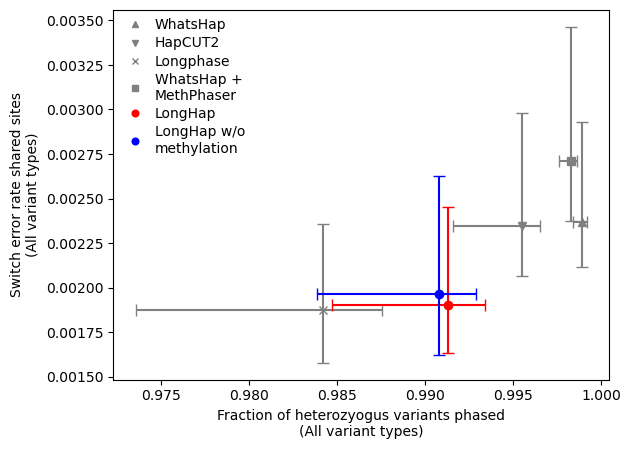

In [12]:
fig, ax = plt.subplots()
plot_fraction_phased_vs_error_rate(eval_dict, stats_dict, tools, 
                                           "Fraction of heterozyogus variants phased\n(All variant types)", 
                                           "Switch error rate shared sites\n(All variant types)", ax=ax)
fig.savefig('fraction_phased_vs_switch_error_{seq_tech}.png', bbox_inches='tight', dpi=600)

## Computational tractability

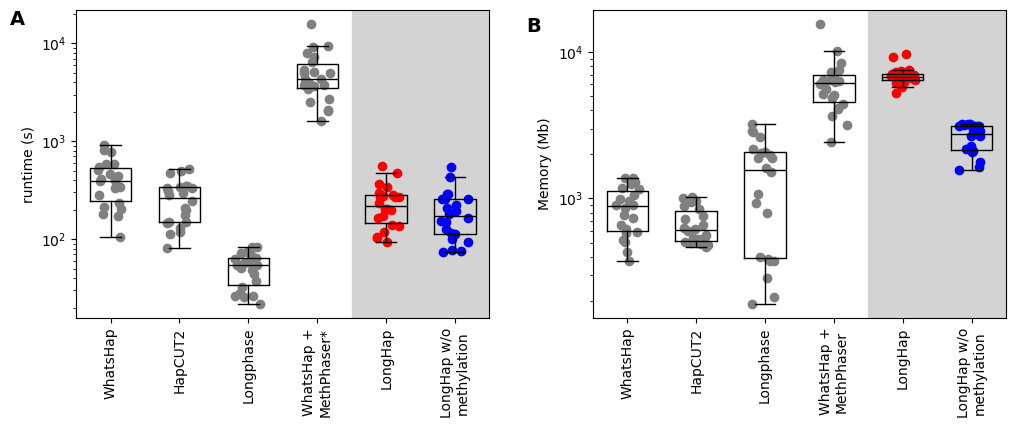

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plt.subplots_adjust(wspace=0.25)

ax[0] = make_box_plot(compute_dict, tools, colors, 's', 'runtime (s)', ax=ax[0])
ax[0].annotate("A", (-0.16, 0.95), xycoords=ax[0].transAxes, fontsize=14, fontweight='bold')
ax[0].axvspan(3.5, 5.5, color='lightgrey', zorder=0)
ax[0].set_xticklabels(['WhatsHap', 'HapCUT2', 'Longphase', "WhatsHap +\nMethPhaser*",
                       'LongHap', 'LongHap w/o\nmethylation'])
ax[0].set_yscale('log')

ax[1] = make_box_plot(compute_dict, tools, colors, 'max_rss', 'Memory (Mb)', ax=ax[1])
ax[1].annotate("B", (-0.16, 0.93), xycoords=ax[1].transAxes, fontsize=14, fontweight='bold')
ax[1].axvspan(3.5, 5.5, color='lightgrey', zorder=0)
ax[1].set_xticklabels(['WhatsHap', 'HapCUT2', 'Longphase', "WhatsHap +\nMethPhaser",
                       'LongHap', 'LongHap w/o\nmethylation'])
ax[1].set_yscale('log')
fig.savefig(f'computational_tractibility_{seq_tech}.png', bbox_inches='tight', dpi=600)

In [16]:
for tool in tools:
    print(f"{tool} max RSS: {compute_dict[tool]['max_rss'].min()}-{compute_dict[tool]['max_rss'].max()} Mb")



WhatsHap max RSS: 373.07-1388.98 Mb
HapCUT2 max RSS: 466.26-1022.61 Mb
Longphase max RSS: 190.96-3211.79 Mb
WhatsHap + MethPhaser max RSS: 2412.31-15518.34 Mb
LongHap Meth max RSS: 5240.54-9709.68 Mb
LongHap max RSS: 1562.09-3234.34 Mb


In [17]:
for tool in tools:
    print(f"{tool} runtime: {compute_dict[tool]['s'].min()}-{compute_dict[tool]['s'].max()} sec")

WhatsHap runtime: 105.6768-912.1121 sec
HapCUT2 runtime: 81.1787-521.8289 sec
Longphase runtime: 21.8147-83.8271 sec
WhatsHap + MethPhaser runtime: 1624.4348-15809.9345 sec
LongHap Meth runtime: 94.2192-557.3194 sec
LongHap runtime: 73.5045-546.8323 sec


## Differentially methylated sites

In [18]:
diff_meth = pd.concat([pd.read_csv(base_dir + f"deep_variant_hifi_hs1.minimap2.{seq_tech}.chr{chrom}.filtered_snps.longhap_meth_diff_meth_sites.tab",
                                   sep='\t') for chrom in np.arange(1, 23)])
diff_meth = diff_meth.groupby(['chrom', 'start', 'end', 'hap']).mean().reset_index()



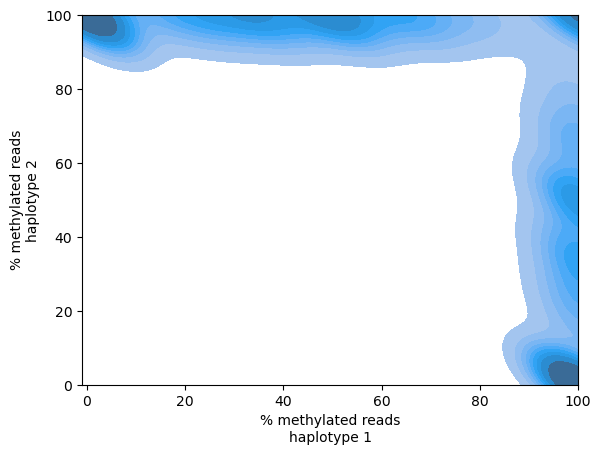

In [19]:
fig, ax = plt.subplots()

diff_meth_sns = diff_meth[diff_meth.hap == "hap1"].set_index(['chrom', 'start', 'end'])
diff_meth_sns.drop(['hap', 'score', 'coverage', 'mod_count', 'unmod_count'], axis=1, inplace=True)
diff_meth_sns.rename({'ratio': 'ratio_hap1'}, axis=1, inplace=True)
diff_meth_sns = diff_meth_sns.join(diff_meth[diff_meth.hap == "hap2"].set_index(['chrom', 'start', 'end']))
diff_meth_sns.drop(['hap', 'score', 'coverage', 'mod_count', 'unmod_count'], axis=1, inplace=True)
diff_meth_sns.rename({'ratio': 'ratio_hap2'}, axis=1, inplace=True)

sns.kdeplot(data=diff_meth_sns, x="ratio_hap1", y="ratio_hap2", fill=True, ax=ax)
ax.set_xlabel('% methylated reads\nhaplotype 1')
ax.set_ylabel('% methylated reads\nhaplotype 2')
ax.set_xlim([-1, 100])
ax.set_ylim([0, 100])
fig.savefig(f'methylation_patterns_differentially_methylated_sites_{seq_tech}.png', bbox_inches='tight', dpi=600)

In [20]:
df = pd.concat([pd.read_csv(f'{base_dir}deep_variant_hifi_hs1.minimap2.{seq_tech}.chr{chrom}.filtered_snps_indels.longhap_blocks.bed',
                            sep='\t', names=['chrom', 'start', 'end']) for chrom in np.arange(1, 23)])
df.reset_index(inplace=True, drop=True)

df_meth = pd.concat([pd.read_csv(f'{base_dir}deep_variant_hifi_hs1.minimap2.{seq_tech}.chr{chrom}.filtered_snps_indels.longhap_meth_blocks.bed',
                            sep='\t', names=['chrom', 'start', 'end']) for chrom in np.arange(1, 23)])
df_meth.reset_index(inplace=True, drop=True)
    

In [22]:
overlap = BedTool.from_dataframe(df_meth).intersect(BedTool.from_dataframe(df), c=True).to_dataframe()
overlap = overlap[overlap['name'] > 1]
df['index'] = df.index
connected = BedTool.from_dataframe(df).intersect(BedTool.from_dataframe(overlap), u=True).to_dataframe()

In [23]:
connected_ranges = []
p_chrom, p_start, p_end, p_idx = connected.loc[0, ['chrom', 'start', 'end', 'name']].values
for (r, (chrom, start, end, idx)) in connected.iloc[1:].iterrows():
    if idx - p_idx == 1 and chrom == p_chrom:
        connected_ranges.append((chrom, p_end, start, start - p_end))
    p_chrom = chrom
    p_start = start
    p_end = end
    p_idx = idx
        

In [24]:
connected_ranges = pd.DataFrame(connected_ranges, columns=['chrom', 'start', 'end', 'dist'])

In [25]:
columns = connected_ranges.columns.values.tolist()
columns.append('diff_meth')
connected_ranges = BedTool.from_dataframe(connected_ranges).intersect(BedTool.from_dataframe(diff_meth), 
                                                                      c=True).to_dataframe(names=columns)

In [26]:
print(f'Mean dist: {connected_ranges.dist.mean() / 1000}')
print(f'Median dist: {connected_ranges.dist.median() / 1000}')
print(f'Max dist: {connected_ranges.dist.max() / 1000}')
print(f'SD dist: {connected_ranges.dist.std() / 1000}')
print(f'Mean diff meth: {connected_ranges.diff_meth.mean()}')
print(f'Median diff meth: {connected_ranges.diff_meth.median()}')
print(f'SD diff meth: {connected_ranges.diff_meth.std()}')

Mean dist: 32.005813079551004
Median dist: 29.289
Max dist: 232.961
SD dist: 12.127192575424472
Mean diff meth: 18.751098096632504
Median diff meth: 12.0
SD diff meth: 20.226175462563926


## CMRGs

In [ ]:
# !wget https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/release/AshkenazimTrio/HG002_NA24385_son/CMRG_v1.00/GRCh38/SupplementaryFiles/GRCh38_CMRG_benchmark_gene_coordinates.bed

In [27]:
cmrgs = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/reference/hs1_CMRG_benchmark_gene_coordinates.bed', 
                    sep='\t', names=['chrom', 'start', 'end', 'gene'])

In [28]:
cmrgs_merged = cmrgs.groupby('gene').min()
cmrgs_merged['end'] = cmrgs.groupby('gene').max()['end'].values
cmrgs_merged = cmrgs_merged.reset_index(drop=False).sort_values(['chrom', 'start'])
cmrgs_merged = cmrgs_merged.loc[:, ['chrom', 'start', 'end', 'gene']]


In [29]:
longhap_blocks = pd.concat([pd.read_csv(f'{base_dir}deep_variant_hifi_hs1.minimap2.{seq_tech}.chr{chrom}.filtered_snps_indels.longhap_phased.stats.gtf',
                                        sep='\t', names=['chrom', 'start', 'end'], usecols=[0, 3, 4]) 
                            for chrom in np.arange(1, 23)])
longhap_blocks.reset_index(inplace=True, drop=True)


longhap_meth_blocks = pd.concat([pd.read_csv(f'{base_dir}deep_variant_hifi_hs1.minimap2.{seq_tech}.chr{chrom}.filtered_snps_indels.longhap_meth_phased.stats.gtf',
                                             sep='\t', names=['chrom', 'start', 'end'], usecols=[0, 3, 4]) 
                                 for chrom in np.arange(1, 23)])
longhap_meth_blocks.reset_index(inplace=True, drop=True)


longphase_blocks = pd.concat([pd.read_csv(f'{base_dir}deep_variant_hifi_hs1.minimap2.{seq_tech}.chr{chrom}.filtered_snps_indels.longphase_phased.stats.gtf',
                                          sep='\t', names=['chrom', 'start', 'end'], usecols=[0, 3, 4]) 
                              for chrom in np.arange(1, 23)])
longphase_blocks.reset_index(inplace=True, drop=True)


whatshap_blocks = pd.concat([pd.read_csv(f'{base_dir}deep_variant_hifi_hs1.minimap2.{seq_tech}.chr{chrom}.filtered_snps_indels.whatshap_phased.stats.gtf',
                                         sep='\t', names=['chrom', 'start', 'end'], usecols=[0, 3, 4]) 
                             for chrom in np.arange(1, 23)])
whatshap_blocks.reset_index(inplace=True, drop=True)


hapcut_blocks = pd.concat([pd.read_csv(f'{base_dir}deep_variant_hifi_hs1.minimap2.{seq_tech}.chr{chrom}.filtered_snps_indels.hapcut2_phased.stats.gtf',
                                       sep='\t', names=['chrom', 'start', 'end'], usecols=[0, 3, 4]) 
                           for chrom in np.arange(1, 23)])
hapcut_blocks.reset_index(inplace=True, drop=True)


whatshap_methphaser_blocks = pd.concat([pd.read_csv(f'{base_dir}deep_variant_hifi_hs1.minimap2.{seq_tech}.chr{chrom}.filtered_snps_indels.whatshap_and_methphaser_phased.stats.gtf',
                                                    sep='\t', names=['chrom', 'start', 'end'], usecols=[0, 3, 4]) 
                                        for chrom in np.arange(1, 23)])
whatshap_methphaser_blocks.reset_index(inplace=True, drop=True)

In [30]:
cmrgs_merged_longhap = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(longhap_blocks), 
                                                                      c=True).to_dataframe()
cmrgs_merged_longhap_meth = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(longhap_meth_blocks), 
                                                                           c=True).to_dataframe()
cmrgs_merged_whatshap = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(whatshap_blocks), 
                                                                           c=True).to_dataframe()
cmrgs_merged_hapcut = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(hapcut_blocks), 
                                                                           c=True).to_dataframe()
cmrgs_merged_longphase = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(longphase_blocks), 
                                                                           c=True).to_dataframe()
cmrgs_merged_whatshap_methphaser = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(whatshap_methphaser_blocks), 
                                                                           c=True).to_dataframe()

In [31]:
print(f'LongHap: {np.sum(cmrgs_merged_longhap.score)}')
print(f'LongHap Meth: {np.sum(cmrgs_merged_longhap_meth.score)}')
print(f'WhatsHap: {np.sum(cmrgs_merged_whatshap.score)}')
print(f'HapCUT2: {np.sum(cmrgs_merged_hapcut.score)}')
print(f'LongPhase: {np.sum(cmrgs_merged_longphase.score)}')
print(f'WhatsHap + Methphaser: {np.sum(cmrgs_merged_whatshap_methphaser.score)}')

LongHap: 714
LongHap Meth: 635
WhatsHap: 774
HapCUT2: 759
LongPhase: 741
WhatsHap + Methphaser: 873


In [32]:
print(f'LongHap: {np.sum(cmrgs_merged_longhap.score > 0)}')
print(f'LongHap Meth: {np.sum(cmrgs_merged_longhap_meth.score > 0)}')
print(f'WhatsHap: {np.sum(cmrgs_merged_whatshap.score > 0)}')
print(f'HapCUT2: {np.sum(cmrgs_merged_hapcut.score > 0)}')
print(f'LongPhase: {np.sum(cmrgs_merged_longphase.score > 0)}')
print(f'WhatsHap + Methphaser: {np.sum(cmrgs_merged_whatshap_methphaser.score > 0)}')

LongHap: 248
LongHap Meth: 250
WhatsHap: 254
HapCUT2: 253
LongPhase: 254
WhatsHap + Methphaser: 254


In [33]:
cmrgs_merged_longhap = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(longhap_blocks), 
                                                                      c=True, f=1).to_dataframe()
cmrgs_merged_longhap_meth = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(longhap_meth_blocks), 
                                                                           c=True, f=1).to_dataframe()
cmrgs_merged_whatshap = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(whatshap_blocks), 
                                                                           c=True, f=1).to_dataframe()
cmrgs_merged_hapcut = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(hapcut_blocks), 
                                                                           c=True, f=1).to_dataframe()
cmrgs_merged_longphase = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(longphase_blocks), 
                                                                           c=True, f=1).to_dataframe()
cmrgs_merged_whatshap_methphaser = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(whatshap_methphaser_blocks), 
                                                                           c=True, f=1).to_dataframe()

In [34]:
print(f'LongHap: {np.sum(cmrgs_merged_longhap.score == 1)}')
print(f'LongHap Meth: {np.sum(cmrgs_merged_longhap_meth.score == 1)}')
print(f'WhatsHap: {np.sum(cmrgs_merged_whatshap.score == 1)}')
print(f'HapCUT2: {np.sum(cmrgs_merged_hapcut.score == 1)}')
print(f'LongPhase: {np.sum(cmrgs_merged_longphase.score == 1)}')
print(f'WhatsHap + Methphaser: {np.sum(cmrgs_merged_whatshap_methphaser.score == 1)}')

LongHap: 206
LongHap Meth: 211
WhatsHap: 210
HapCUT2: 209
LongPhase: 209
WhatsHap + Methphaser: 209


In [38]:
cmrgs_merged_longhap_meth[(cmrgs_merged_longhap.score  != cmrgs_merged_longhap_meth.score)]

,chrom,start,end,name,score
38,chr11,2082853,2089147,H19,1
134,chr19,43711502,43733047,CYP2G1P,1
171,chr2,242238624,242271346,D2HGDH,1
228,chr5,97592630,97643516,LIX1,1
231,chr5,141381208,141537634,PCDHA10,1


In [39]:
cmrgs_merged_longhap_meth.rename({'score': 'LongHap Meth'}, axis=1, inplace=True)
cmrgs_merged_longhap.rename({'score': 'LongHap'}, axis=1, inplace=True)
cmrgs_merged_longphase.rename({'score': 'LongPhase'}, axis=1, inplace=True)
cmrgs_merged_whatshap.rename({'score': 'WhatsHap'}, axis=1, inplace=True)
cmrgs_merged_hapcut.rename({'score': 'HapCUT2'}, axis=1, inplace=True)
cmrgs_merged_whatshap_methphaser.rename({'score': 'WhatsHap + MethPhaser'}, axis=1, inplace=True)

In [40]:
df_joined = cmrgs_merged_longhap_meth.set_index(['chrom', 'start', 'end', 'name']).join(cmrgs_merged_longhap.set_index(['chrom', 'start', 'end', 'name'])).join(cmrgs_merged_longphase.set_index(['chrom', 'start', 'end', 'name'])).join(cmrgs_merged_whatshap.set_index(['chrom', 'start', 'end', 'name'])).join(cmrgs_merged_hapcut.set_index(['chrom', 'start', 'end', 'name'])).join(cmrgs_merged_whatshap_methphaser.set_index(['chrom', 'start', 'end', 'name']))

In [41]:
df_joined.sum(axis=0)

LongHap Meth             211
LongHap                  206
LongPhase                209
WhatsHap                 210
HapCUT2                  209
WhatsHap + MethPhaser    209
dtype: int64

In [42]:
df_joined[np.sum(df_joined.values > 0, axis=1) == 6]

LongHap Meth  LongHap  LongPhase  WhatsHap  \
chrom start     end       name                                                 
chr1  5710666   5735033   RPL22              1        1          1         1   
      10567802  10588801  MASP2              1        1          1         1   
      11389795  11392430  NPPA               1        1          1         1   
      23636860  23673699  HMGCL              1        1          1         1   
      25198547  25266535  RHCE               1        1          1         1   
...                                        ...      ...        ...       ...   
chr9  145463984 145489899 ABO                1        1          1         1   
      147920187 147931347 SOHLH1             1        1          1         1   
      148657963 148668937 INPP5E             1        1          1         1   
      149322873 149347137 MAN1B1             1        1          1         1   
      149377044 149406436 GRIN1              1        1          1         1   

                                  HapCUT2  WhatsHap + MethPhaser  
chrom start     end       name                                    
chr1  5710666   5735033   RPL22         1                      1  
      10567802  10588801  MASP2         1                      1  
      11389795  11392430  NPPA          1                      1  
      23636860  23673699  HMGCL         1                      1  
      25198547  25266535  RHCE          1                      1  
...                                   ...                    ...  
chr9  145463984 145489899 ABO           1                      1  
      147920187 147931347 SOHLH1        1                      1  
      148657963 148668937 INPP5E        1                      1  
      149322873 149347137 MAN1B1        1                      1  
      149377044 149406436 GRIN1         1                      1  

[204 rows x 6 columns]

In [43]:
df_joined[np.sum(df_joined.values > 0, axis=1) == 6].sum(axis=0)

LongHap Meth             204
LongHap                  204
LongPhase                204
WhatsHap                 204
HapCUT2                  204
WhatsHap + MethPhaser    204
dtype: int64

In [44]:
cmrgs_merged_longhap = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(longhap_blocks), 
                                                                      wo=True).to_dataframe()
cmrgs_merged_longhap.drop(['chrom', 'start', 'end', 'score', 'strand', 'thickStart'], axis=1, inplace=True)
cmrgs_merged_longhap = cmrgs_merged_longhap.groupby('name').sum()

cmrgs_merged_longhap_meth = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(longhap_meth_blocks), 
                                                                           wo=True).to_dataframe()
cmrgs_merged_longhap_meth.drop(['chrom', 'start', 'end', 'score', 'strand', 'thickStart'], axis=1, inplace=True)
cmrgs_merged_longhap_meth = cmrgs_merged_longhap_meth.groupby('name').sum()

cmrgs_merged_whatshap = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(whatshap_blocks), 
                                                                           wo=True).to_dataframe()
cmrgs_merged_whatshap.drop(['chrom', 'start', 'end', 'score', 'strand', 'thickStart'], axis=1, inplace=True)
cmrgs_merged_whatshap = cmrgs_merged_whatshap.groupby('name').sum()

cmrgs_merged_hapcut = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(hapcut_blocks), 
                                                                           wo=True).to_dataframe()
cmrgs_merged_hapcut.drop(['chrom', 'start', 'end','score', 'strand', 'thickStart'], axis=1, inplace=True)
cmrgs_merged_hapcut = cmrgs_merged_hapcut.groupby('name').sum()
cmrgs_merged_longphase = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(longphase_blocks), 
                                                                           wo=True).to_dataframe()
cmrgs_merged_longphase.drop(['chrom', 'start', 'end', 'score', 'strand', 'thickStart'], axis=1, inplace=True)
cmrgs_merged_longphase = cmrgs_merged_longphase.groupby('name').sum()
cmrgs_merged_whatshap_methphaser = BedTool.from_dataframe(cmrgs_merged).intersect(BedTool.from_dataframe(whatshap_methphaser_blocks), 
                                                                           wo=True).to_dataframe()
cmrgs_merged_whatshap_methphaser.drop(['chrom', 'start', 'end', 'score', 'strand', 'thickStart'], axis=1, inplace=True)
cmrgs_merged_whatshap_methphaser = cmrgs_merged_whatshap_methphaser.groupby('name').sum()

In [45]:
print(f'LongHap: {np.sum(cmrgs_merged_longhap.thickEnd) / 1e6}')
print(f'LongHap Meth: {np.sum(cmrgs_merged_longhap_meth.thickEnd) / 1e6}')
print(f'WhatsHap: {np.sum(cmrgs_merged_whatshap.thickEnd) / 1e6}')
print(f'HapCUT2: {np.sum(cmrgs_merged_hapcut.thickEnd) / 1e6}')
print(f'LongPhase: {np.sum(cmrgs_merged_longphase.thickEnd) / 1e6}')
print(f'WhatsHap + Methphaser: {np.sum(cmrgs_merged_whatshap_methphaser.thickEnd) / 1e6}')

LongHap: 125.244024
LongHap Meth: 128.940398
WhatsHap: 127.404373
HapCUT2: 126.691531
LongPhase: 127.293536
WhatsHap + Methphaser: 126.738624


In [46]:
cmrgs_merged_longhap_meth.rename({'thickEnd': 'LongHap Meth'}, axis=1, inplace=True)
cmrgs_merged_longhap.rename({'thickEnd': 'LongHap'}, axis=1, inplace=True)
cmrgs_merged_longphase.rename({'thickEnd': 'LongPhase'}, axis=1, inplace=True)
cmrgs_merged_whatshap.rename({'thickEnd': 'WhatsHap'}, axis=1, inplace=True)
cmrgs_merged_hapcut.rename({'thickEnd': 'HapCUT2'}, axis=1, inplace=True)
cmrgs_merged_whatshap_methphaser.rename({'thickEnd': 'WhatsHap + MethPhaser'}, axis=1, inplace=True)

In [47]:
df_joined = cmrgs_merged_longhap_meth.join(cmrgs_merged_longhap).join(cmrgs_merged_longphase).join(cmrgs_merged_whatshap).join(cmrgs_merged_hapcut).join(cmrgs_merged_whatshap_methphaser)

In [48]:
df_joined[np.all(df_joined > 0, axis=1)].dropna().sum(axis=0) / 1e6

LongHap Meth             128.902016
LongHap                  125.238763
LongPhase                127.189783
WhatsHap                 127.300620
HapCUT2                  126.605348
WhatsHap + MethPhaser    126.669255
dtype: float64